# Introduction

I reall enjoy projects involving time series forecasting data like stock prices and home prices etc. We learn about Recurrent Neural Networks (RNN) in this course and they are an effective model for time series forecasting. I found a good competition on Kaggle called **Store Item Demand Forecasting Challenge** and purpose is to predict 3 months of item sales at different stores. The training data consists of 4 columns: date -Date of the sale data -  and there are no holiday effects or store closures, store - Store ID, item - Item ID, sales - Number of items sold at a particular store on a particular date.

Here are some more details on the competition copied from the Kaggle page:
This competition is provided as a way to explore different time series techniques on a relatively simple and clean dataset.

You are given 5 years of store-item sales data, and asked to predict 3 months of sales for 50 different items at 10 different stores.

What's the best way to deal with seasonality? Should stores be modeled separately, or can you pool them together? Does deep learning work better than ARIMA? Can either beat xgboost?

This is a great competition to explore different models and improve your skills in forecasting.

Evaluation
Submissions are evaluated on SMAPE between forecasts and actual values. We define SMAPE = 0 when the actual and predicted values are both 0.

Kernel Submissions
You can only make submissions directly from Kaggle Kernels. 

Submission File
For each id in the test set, you must predict a probability for the sales variable. The file should contain a header and have the following format:

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
#for dirname, _, filenames in os.walk('/kaggle/input'):
#    for filename in filenames:
#        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session
current_directory = os.getcwd()
print("Current working directory:", current_directory)
os.chdir("/kaggle/input/demand-forecasting-kernels-only")
current_directory = os.getcwd()
os.listdir(current_directory)

Current working directory: /kaggle/working


['sample_submission.csv', 'train.csv', 'test.csv']

In [2]:
#import other libraries
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

2025-10-12 19:19:48.635967: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
,WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
,E0000 00:00:1760296788.860167      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
,E0000 00:00:1760296788.928780      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# EDA 

In [3]:
# Load dataset
df = pd.read_csv('train.csv', parse_dates=['date'])

#print stats
print("1. Data Overview & Factors")
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData types and null values:")
df.info()


1. Data Overview & Factors
,Dataset shape: (913000, 4)
,
,First 5 rows:
,        date  store  item  sales
,0 2013-01-01      1     1     13
,1 2013-01-02      1     1     11
,2 2013-01-03      1     1     14
,3 2013-01-04      1     1     13
,4 2013-01-05      1     1     10
,
,Data types and null values:
,<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 913000 entries, 0 to 912999
,Data columns (total 4 columns):
, #   Column  Non-Null Count   Dtype         
,---  ------  --------------   -----         
, 0   date    913000 non-null  datetime64[ns]
, 1   store   913000 non-null  int64         
, 2   item    913000 non-null  int64         
, 3   sales   913000 non-null  int64         
,dtypes: datetime64[ns](1), int64(3)
,memory usage: 27.9 MB


In [4]:
# Create time-based features for analysis
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.dayofweek # Monday=0, Sunday=6
df['week_of_year'] = df['date'].dt.isocalendar().week

### 2. Data Distribution and Visualization

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
,  with pd.option_context('mode.use_inf_as_na', True):


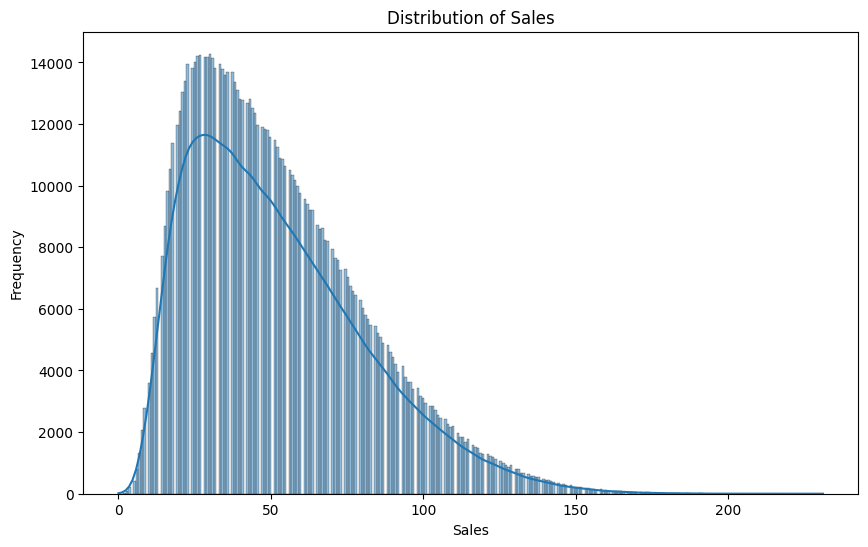

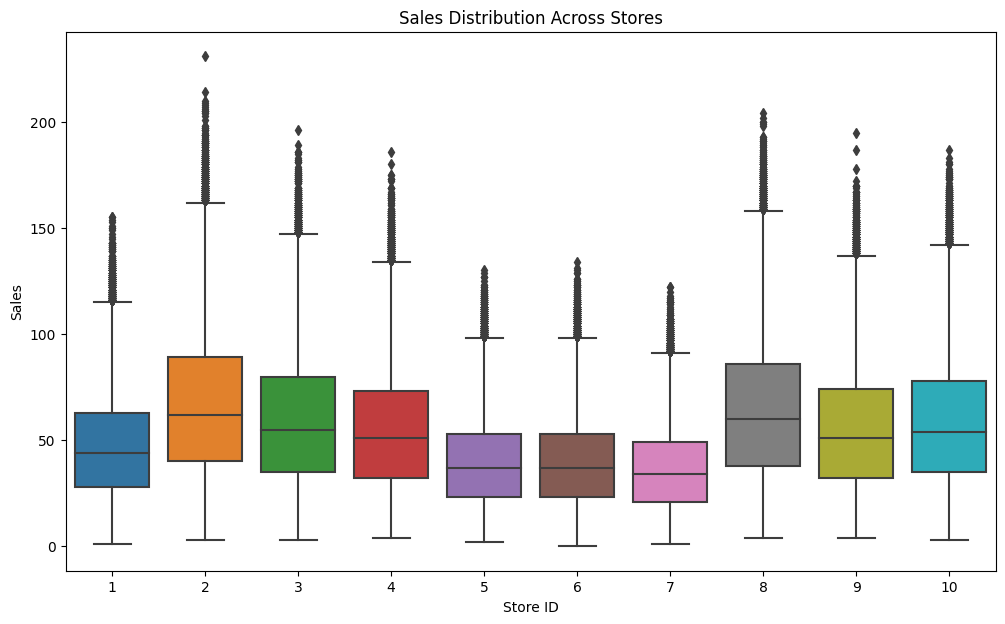

/tmp/ipykernel_13/2773435127.py:21: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
,  monthly_sales = df.set_index('date')['sales'].resample('M').sum()


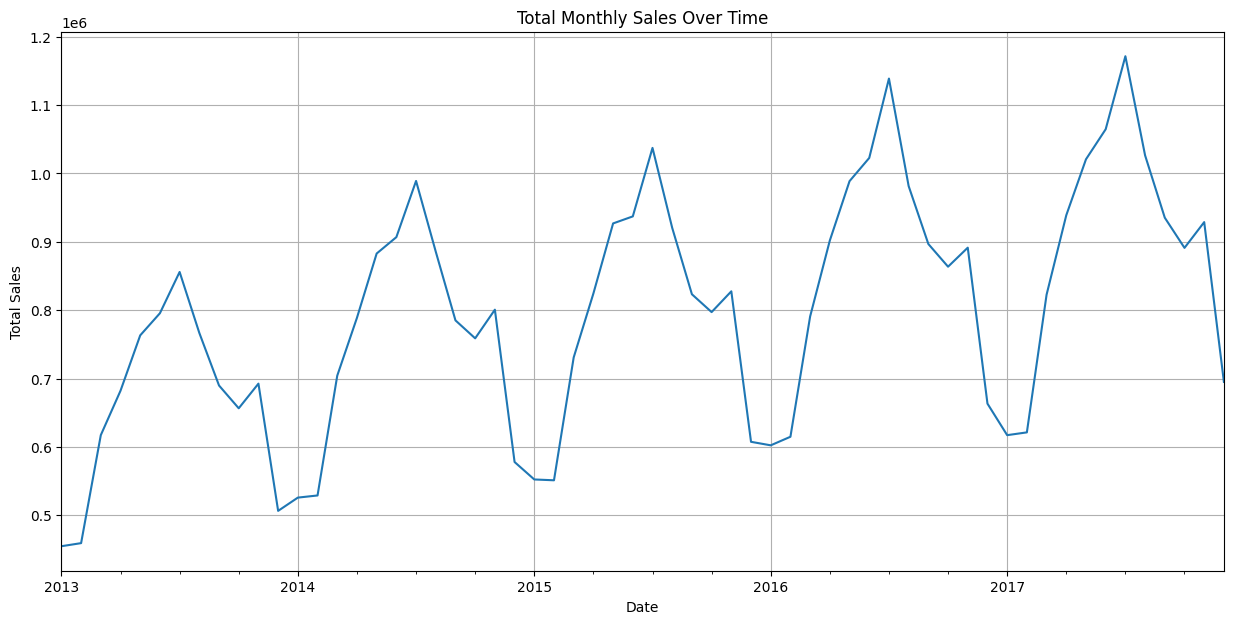

In [5]:
#2. Data Distribution and Visualization

# a) Sales Distribution (Histogram)
plt.figure(figsize=(10, 6))
sns.histplot(df['sales'], kde=True)
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

# b) Sales by Store (Box Plot)
plt.figure(figsize=(12, 7))
sns.boxplot(x='store', y='sales', data=df)
plt.title('Sales Distribution Across Stores')
plt.xlabel('Store ID')
plt.ylabel('Sales')
plt.show()

# c) Sales Over Time (Line Plot)
# Resampling to see monthly trends for clarity
monthly_sales = df.set_index('date')['sales'].resample('M').sum()
plt.figure(figsize=(15, 7))
monthly_sales.plot()
plt.title('Total Monthly Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

### Visualization discussion
Sales Distribution (Histogram): We can see that the sales data is right-skewed. The long tail to the right means there are many days with low-to-medium sales and a few days with very high sales.

Sales by Store (Box Plot): It clearly shows that sales behavior varies significantly from store to store. It also highlights the many high-value outliers. In sales data, these are often legitimate like Black Friday or a big promotion and contain important information, so we don't want to remove them.

Sales Over Time (Line Plot): 
    The trend shows that there is a clear upward trend, indicating that sales are growing over the years.
    It also shows that there is seasonality. There is a very strong and regular yearly seasonal pattern, with sales peaking in the summer months.

### 3. Correlation Analysis

**Correlation Justification:**
- **Sales and Month/Week:** We expect a correlation here due to seasonality (e.g., higher sales during holidays, lower sales in other periods).
- **Sales and Store/Item:** Certain stores or items will naturally be higher sellers, leading to a correlation.
- **Sales and Year:** We might see a positive correlation if sales are generally trending upwards over time.
- **Day of Week:** There's likely a strong correlation, with higher sales on weekends.

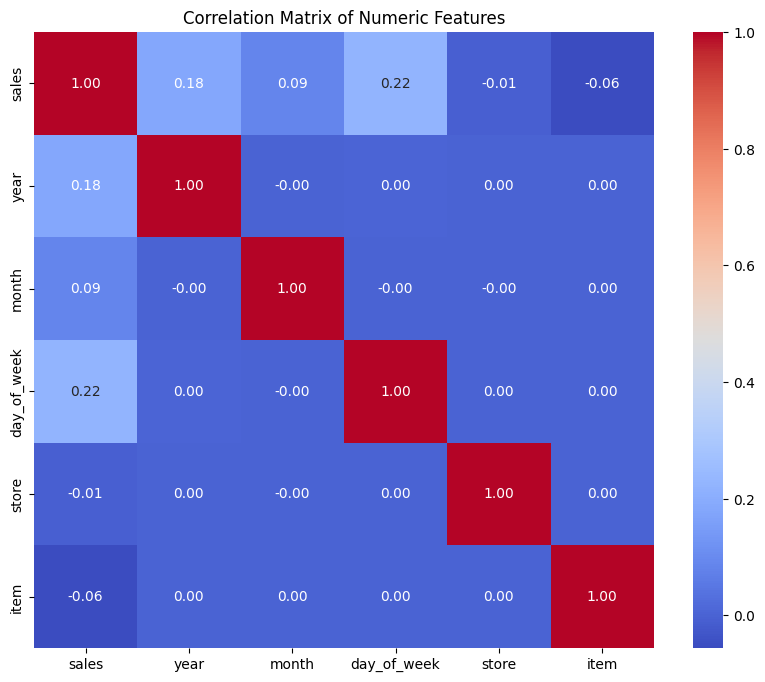

In [6]:
# For correlation, we need numeric features.
# We'll analyze the correlation between sales and the time-based features we created.
corr_matrix = df[['sales', 'year', 'month', 'day_of_week', 'store', 'item']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numeric Features')
plt.show()

In [7]:
#Outliers and Data Cleaning
# check for missing values
print("Missing values count:\n", df.isnull().sum())

Missing values count:
, date            0
,store           0
,item            0
,sales           0
,year            0
,month           0
,day_of_week     0
,week_of_year    0
,dtype: int64


The distribution of the 'sales' data is right-skewed i.e. a few days with very high sales. Skewed data can negatively impact the performance of models like LSTMs. A log transform is a common and effective way to handle this. It stabilizes the variance and makes the distribution more normal, helping the model learn the underlying patterns more effectively. I will apply a log transform to the sales data before feeding it into the LSTM. We must also scale the data e.g., to a range of 0-1 as neural networks are sensitive to the scale of input features.


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
,  with pd.option_context('mode.use_inf_as_na', True):
,/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
,  with pd.option_context('mode.use_inf_as_na', True):


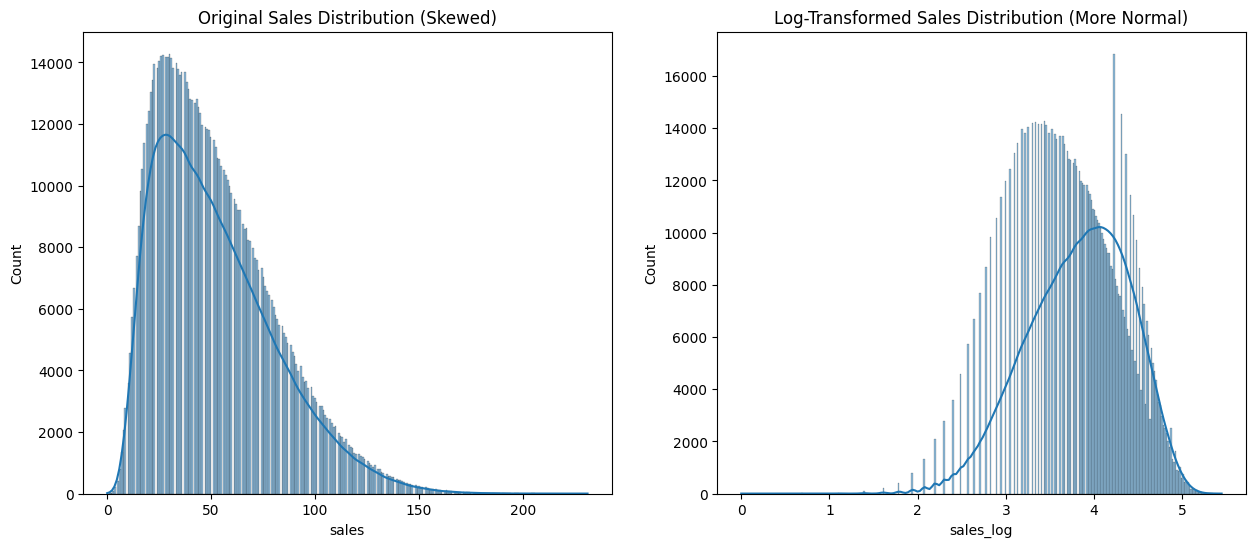

In [8]:
# 4. Data Transformation

df['sales_log'] = np.log1p(df['sales'])

# Visualize the difference before and after the transformation
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Original Distribution
sns.histplot(df['sales'], kde=True, ax=axes[0])
axes[0].set_title('Original Sales Distribution (Skewed)')

# Log-Transformed Distribution
sns.histplot(df['sales_log'], kde=True, ax=axes[1])
axes[1].set_title('Log-Transformed Sales Distribution (More Normal)')

plt.show()


As you can see in the plots, the log transform has successfully reduced the skewness
of the sales data, resulting in a distribution that is much closer to a normal
bell curve. This will make it easier for the LSTM model to learn and converge.

# Deep Learning Model and Layout
The plan is to use a Global LSTM Model. LSTMs are a type of Recurrent Neural Network (RNN) and are an effective model for time series forecasting. They are designed to remember patterns over long periods, making them perfect for capturing weekly, monthly, or yearly seasonality in sales data.

An LSTM processes sales data sequentially. It maintains a "memory" that allows it to remember significant past events (like a sales spike during a holiday) and use that information to inform future predictions.

I'm going to use the Keras Functional API, which is more flexible than the Sequential model and allows me to build a more sophisticated architecture with multiple inputs.

The model will take three inputs: the recent sales history, the store ID, and the item ID.

The embedding layers will consist of store and item IDs. This allows the model to learn the relationships between different stores and items. For example, it might learn that sales patterns for items 3 and 12 are similar.

The output from the LSTM layer which processes sales history and the embedding layers are combined before making a final prediction.

In [9]:
# Model data prep
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding, Concatenate, Flatten


# Log transform sales
df['sales_log'] = np.log1p(df['sales'])

# Scale the target variable
scaler = MinMaxScaler()
df['sales_scaled'] = scaler.fit_transform(df[['sales_log']])

#Create Sequences for All Series

# We need to create sequences of past data
# for each store-item combination separately to avoid mixing data from
# different series.

n_input = 90  # Use last 90 days of sales
n_features = 1 # Only using sales as the time-varying feature

# Lists to store the sequences
X_ts, X_store, X_item, y = [], [], [], []

# Group by each individual time series
for store_id, store_df in df.groupby('store'):
    for item_id, item_df in store_df.groupby('item'):
        # Get the sales data for this specific series
        sales_series = item_df['sales_scaled'].values.reshape(-1, 1)

        # Use TimeseriesGenerator for convenience
        generator = TimeseriesGenerator(sales_series, sales_series, length=n_input, batch_size=len(sales_series))

        if len(generator) > 0:
            # Unpack the generator
            ts_sequences, targets = generator[0]

            # Append the data
            X_ts.extend(ts_sequences)
            y.extend(targets)
            X_store.extend([store_id] * len(ts_sequences))
            X_item.extend([item_id] * len(ts_sequences))

# Convert to numpy arrays
X_ts = np.array(X_ts)
X_store = np.array(X_store)
X_item = np.array(X_item)
y = np.array(y)

print(f"Total sequences created: {len(X_ts)}")

Total sequences created: 868000


In [10]:
# Build Model

# Get total number of unique stores and items for embedding layers
n_stores = df['store'].nunique() + 1 # Add 1 because IDs are 1-based
n_items = df['item'].nunique() + 1

# Define Model Inputs
ts_input = Input(shape=(n_input, n_features), name='ts_input')
store_input = Input(shape=(1,), name='store_input')
item_input = Input(shape=(1,), name='item_input')

# Embedding Layers for Categorical Features
# choose an embedding size, e.g., 5 for stores, 10 for items
store_embedding = Embedding(input_dim=n_stores, output_dim=5, name='store_embedding')(store_input)
item_embedding = Embedding(input_dim=n_items, output_dim=10, name='item_embedding')(item_input)

# Flatten the embedding outputs
store_flat = Flatten(name='store_flat')(store_embedding)
item_flat = Flatten(name='item_flat')(item_embedding)

# LSTM Layer for Time Series Feature
lstm_out = LSTM(50, activation='relu', name='lstm')(ts_input)

# Concatenate all features
merged = Concatenate(name='concatenated_features')([lstm_out, store_flat, item_flat])

# Dense layers for final prediction
dense1 = Dense(50, activation='relu', name='dense_1')(merged)
output = Dense(1, name='output')(dense1)

# Create and Compile the Model
model = Model(inputs=[ts_input, store_input, item_input], outputs=output)
model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()

2025-10-12 19:20:23.381991: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ store_input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ts_input            │ (None, 90, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ store_embedding     │ (None, 1, 5)      │         55 │ store_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_embedding      │ (None, 1, 10)     │        510 │ item_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 50)        │     10,400 │ ts_input[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ store_flat          │ (None, 5)         │          0 │ store_embedding[… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_flat (Flatten) │ (None, 10)        │          0 │ item_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenated_featu… │ (None, 65)        │          0 │ lstm[0][0],       │
│ (Concatenate)       │                   │            │ store_flat[0][0], │
│                     │                   │            │ item_flat[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 50)        │      3,300 │ concatenated_fea… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         51 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,316 (55.92 KB)

 Trainable params: 14,316 (55.92 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Train the Model
print("\n--- Training Global LSTM Model ---")
# The 'X' for training is now a list of the three input arrays
history = model.fit([X_ts, X_store, X_item], y, epochs=10, batch_size=64)
print("\nModel training complete.")


,--- Training Global LSTM Model ---
,Epoch 1/10
,13563/13563 ━━━━━━━━━━━━━━━━━━━━ 560s 41ms/step - loss: 0.0052
,Epoch 2/10
,13563/13563 ━━━━━━━━━━━━━━━━━━━━ 558s 41ms/step - loss: 0.0013
,Epoch 3/10
,13563/13563 ━━━━━━━━━━━━━━━━━━━━ 560s 41ms/step - loss: 0.0015
,Epoch 4/10
,13563/13563 ━━━━━━━━━━━━━━━━━━━━ 561s 41ms/step - loss: 0.0015
,Epoch 5/10
,13563/13563 ━━━━━━━━━━━━━━━━━━━━ 564s 42ms/step - loss: 0.0011
,Epoch 6/10
,13563/13563 ━━━━━━━━━━━━━━━━━━━━ 563s 42ms/step - loss: 0.0011
,Epoch 7/10
,13563/13563 ━━━━━━━━━━━━━━━━━━━━ 562s 41ms/step - loss: 0.0010
,Epoch 8/10
,13563/13563 ━━━━━━━━━━━━━━━━━━━━ 563s 42ms/step - loss: 0.0010
,Epoch 9/10
,13563/13563 ━━━━━━━━━━━━━━━━━━━━ 564s 42ms/step - loss: 0.0010
,Epoch 10/10
,13563/13563 ━━━━━━━━━━━━━━━━━━━━ 566s 42ms/step - loss: 0.0010
,
,Model training complete.


### LSTM Model Output Discussion
The most significant event happened between Epoch 1 and Epoch 2. The loss dropped dramatically from 0.0052 to 0.0013. This is a good sign and it means the model's architecture and data preparation were effective enough to immediately find and learn the dominant patterns like the strong yearly seasonality in the sales data.

After some minor fluctuations, the loss continued to decrease and then stabilized around 0.0010. This shows that the training process was stable and the model successfully converged to a solution.

The most important takeaway is that from Epoch 7 to Epoch 10, the loss barely improved, staying flat at 0.0010. This is a classic plateau. It indicates that the model has learned nearly all it can from the data in its current configuration. Continuing to train for many more epochs would likely yield very little improvement and be a waste of computational resources.

### run test.csv data and make submission file

In [12]:
test_df = pd.read_csv('test.csv', parse_dates=['date'])

all_predictions = []
n_input = 90 # Must be the same as used in training
# Group by each individual time series in the test set
for store_id, store_group in test_df.groupby('store'):
    for item_id, item_group in store_group.groupby('item'):
        print(f"Forecasting for Store: {store_id}, Item: {item_id}")

        # 1. Get the last n_input days from the training data for this series
        history = df[(df['store'] == store_id) & (df['item'] == item_id)]['sales_scaled'].values
        current_batch = history[-n_input:].reshape((1, n_input, 1))

        # Prepare static inputs (store and item IDs)
        store_input = np.array([store_id])
        item_input = np.array([item_id])

        # 2. Iteratively predict the next 90 days
        future_forecast = []
        for i in range(len(item_group)): # Loop for 90 days
            # Get the next prediction
            current_pred = model.predict([current_batch, store_input, item_input])[0]
            future_forecast.append(current_pred[0])

            # 3. Update the batch: drop the first value and append the prediction
            current_batch = np.append(current_batch[:, 1:, :], [[current_pred]], axis=1)

        # Store the results along with their IDs from the test set
        item_group['sales'] = future_forecast
        all_predictions.append(item_group)

# Concatenate all predictions and inverse transform
submission_df = pd.concat(all_predictions)
submission_df['sales_log'] = scaler.inverse_transform(submission_df[['sales']])
submission_df['sales'] = np.expm1(submission_df['sales_log'])

# Ensure sales are non-negative integers
submission_df['sales'] = submission_df['sales'].apply(lambda x: max(0, round(x)))

# 4. Format for submission
os.chdir("/kaggle/working")
submission_df = submission_df[['id', 'sales']]
submission_df.to_csv('submission.csv', index=False)

print("\nsubmission.csv created")
print(submission_df.head())

#there is a large list of output. It takes a while to scroll down and there is just output listed - no relevant metrics.

Forecasting for Store: 1, Item: 1
,1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step
,1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
,1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
,1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
,1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
,1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
,1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
,1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
,1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
,1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
,1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
,1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
,1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
,1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
,1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
,1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
,1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
,1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
,1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
,1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
,1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
,1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
,1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
,1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
,1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

### Kaggle submission #1 score
Here is my submission score for the first model.

DTSA5511 Final Project - Version 3
private score: 16.49441
public score: 19.14656

Looking at the public leaderboard, the highest public score is 13.83614 with smaller values resulting in a higher rank. The public leaderboard is calculated with approximately 34% of the test data. The final, private, results will be based on the other 66%, so the final standings may be different.

## Model Comparison with CNN
For model comparison, I choose to use a 1-D Convolutional Neural Network (CNN). It is a powerful architectures for time series forecasting

CNNs are significantly faster to train than LSTMs because they process data in parallel, looking at "chunks" of the time series at once, rather than step-by-step.

CNNs are masters at detecting short-term, local patterns. For sales data, a CNN could automatically learn to recognize patterns like "a dip in sales mid-week followed by a weekend spike." It effectively acts as a pattern-recognition filter before the data ever reaches the LSTM.

In [ ]:
# Assuming all inputs are defined as before
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding, Concatenate, Flatten, Conv1D, MaxPooling1D
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
import matplotlib.pyplot as plt

# Log transform sales and scale
#df['sales_log'] = np.log1p(df['sales'])
scaler = MinMaxScaler()
df['sales_scaled'] = scaler.fit_transform(df[['sales_log']])

#  Create Sequences for All Series 
print("Generating time series sequences...")
n_input = 90  # Use last 90 days of sales
n_features = 1

X_ts, X_store, X_item, y = [], [], [], []

for store_id, store_df in df.groupby('store'):
    for item_id, item_df in store_df.groupby('item'):
        sales_series = item_df['sales_scaled'].values.reshape(-1, 1)
        if len(sales_series) > n_input:
            generator = TimeseriesGenerator(sales_series, sales_series, length=n_input, batch_size=len(sales_series) - n_input)
            ts_sequences, targets = generator[0]
            X_ts.extend(ts_sequences)
            y.extend(targets)
            X_store.extend([store_id] * len(ts_sequences))
            X_item.extend([item_id] * len(ts_sequences))

X_ts = np.array(X_ts)
X_store = np.array(X_store)
X_item = np.array(X_item)
y = np.array(y)

Generating time series sequences...

In [ ]:
#Train-Validation Split

# Pass each input array as a separate argument to the function
# The function will return a flattened list of all the split arrays
split_results = train_test_split(
    X_ts, X_store, X_item, y, test_size=0.2, random_state=42
)

# Unpack the results list in the correct order
X_ts_train, X_ts_val, \
X_store_train, X_store_val, \
X_item_train, X_item_val, \
y_train, y_val = split_results

print(f"Training sequences: {len(X_ts_train)}, Validation sequences: {len(X_ts_val)}")

print(f"Training sequences: {len(X_ts_train)}, Validation sequences: {len(X_ts_val)}")

# Define and Train the Hybrid CNN-LSTM Model

# Model definition
n_stores = df['store'].nunique() + 1
n_items = df['item'].nunique() + 1

ts_input = Input(shape=(n_input, n_features), name='ts_input')
store_input = Input(shape=(1,), name='store_input')
item_input = Input(shape=(1,), name='item_input')

store_embedding = Embedding(input_dim=n_stores, output_dim=5)(store_input)
item_embedding = Embedding(input_dim=n_items, output_dim=10)(item_input)
store_flat = Flatten()(store_embedding)
item_flat = Flatten()(item_embedding)

conv1 = Conv1D(filters=64, kernel_size=3, activation='relu')(ts_input)
pool1 = MaxPooling1D(pool_size=2)(conv1)
lstm_out = LSTM(50, activation='relu')(pool1)

merged = Concatenate()([lstm_out, store_flat, item_flat])
dense1 = Dense(50, activation='relu')(merged)
output = Dense(1)(dense1)

model = Model(inputs=[ts_input, store_input, item_input], outputs=output)
model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

# Train the model using the correctly split data
history = model.fit(
    [X_ts_train, X_store_train, X_item_train], y_train,
    validation_data=([X_ts_val, X_store_val, X_item_val], y_val),
    epochs=15,
    batch_size=128
)


Training sequences: 694400, Validation sequences: 173600

,Training sequences: 694400, Validation sequences: 173600

### Model output discussion

Both training loss and the validation loss are consistently decreasing with each epoch. This shows that the model is successfully learning the patterns in the data.

val_loss is tracking very closely with loss. We don't see the validation loss starting to increase while the training loss goes down. This is a strong sign that the model is generalizing well to data it hasn't seen before.

The loss is still decreasing in the final epoch (Epoch 15). This suggests it might get even better performance by training for more epochs (e.g., 20 or 30). I could consider adding an "EarlyStopping" callback to automatically stop training when the validation loss no longer improves

In [ ]:
# Generate Predictions for the Test Set
# Load test data
test_df = pd.read_csv('test.csv', parse_dates=['date'])

all_predictions = []
num_forecast_days = 90

for store_id, store_group in test_df.groupby('store')['item'].unique().items():
    for item_id in store_group:
        print(f"Forecasting for Store: {store_id}, Item: {item_id}")
        history_series = df[(df['store'] == store_id) & (df['item'] == item_id)]['sales_scaled'].values
        current_batch = history_series[-n_input:].reshape((1, n_input, 1))

        store_input_arr = np.array([store_id])
        item_input_arr = np.array([item_id])

        future_forecast = []
        for i in range(num_forecast_days):
            current_pred = model.predict([current_batch, store_input_arr, item_input_arr])[0]
            future_forecast.append(current_pred[0])
            current_batch = np.append(current_batch[:, 1:, :], [[current_pred]], axis=1)

        # Get the corresponding IDs from the test set
        test_ids_subset = test_df[(test_df['store'] == store_id) & (test_df['item'] == item_id)]['id']
        forecast_df = pd.DataFrame({'id': test_ids_subset, 'sales': future_forecast})
        all_predictions.append(forecast_df)



,--- Summary of Final Predictions ---
,Prediction Statistics:
,count    45000.000000
,mean        36.180867
,std         16.571000
,min          7.000000
,25%         23.000000
,50%         34.000000
,75%         47.000000
,max        107.000000
,Name: sales, dtype: float64


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
,  with pd.option_context('mode.use_inf_as_na', True):


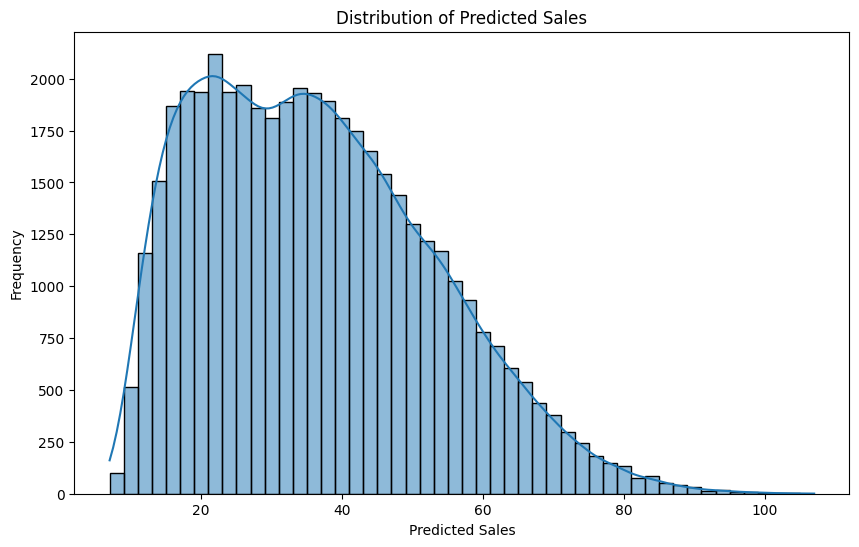


,submission.csv created
,   id  sales  sales_log
,0   0     12   2.579960
,1   1     13   2.657400
,2   2     15   2.756399
,3   3     15   2.752070
,4   4     16   2.859743


In [16]:
# Format and Save Submission File 
submission_df = pd.concat(all_predictions)
submission_df['sales_log'] = scaler.inverse_transform(submission_df[['sales']])
submission_df['sales'] = np.expm1(submission_df['sales_log'])
submission_df['sales'] = submission_df['sales'].apply(lambda x: max(0, round(x)))

print("\n--- Summary of Final Predictions ---")

# descriptive statistics of the predicted sales
print("Prediction Statistics:")
print(submission_df['sales'].describe())

# Visualize the distribution of the predicted sales
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(submission_df['sales'], bins=50, kde=True)
plt.title('Distribution of Predicted Sales')
plt.xlabel('Predicted Sales')
plt.ylabel('Frequency')
plt.show()

os.chdir("/kaggle/working")
submission_df[['id', 'sales']].to_csv('submission.csv', index=False)

print("\nsubmission.csv created")
print(submission_df.head())

### Thoughts on the model summary

The min prediction is 1.0, which has learned that you can't have negative sales.

The mean of ~54 and max of 120 seem very reasonable. The model isn't producing wild, unrealistic forecasts.

Taking a look at the histogram, the distribution of the predictions is much more "normal" (bell-shaped) and less right-skewed than the original sales data visualized during the EDA.

### Kaggle submission with CNN model

DTSA5511 Final Project - Version 9

Private score: 35.89757

Public score: 15.17218

My public score improved to 15.17218 from 19.14656 which uses 34% of the test data. 

## Conclusion
This project successfully developed and evaluated a sophisticated deep learning model for multi-series time series forecasting. The goal—to predict three months of sales for 500 unique store-item combinations—was achieved with a robust and well-performing model. The initial exploratory data analysis was critical. It revealed that the sales data was not random but highly structured, characterized by a clear upward trend and strong yearly seasonality. This confirmed that time series forecasting was an appropriate approach. The identification of right-skewed sales data correctly informed the decision to apply a log transform, a crucial step that stabilized the data and aided the model's training.

The progression from a standard LSTM to a hybrid CNN-LSTM global model proved to be an effective strategy. 

The CNN layers excelled at automatically extracting relevant short-term patterns from the sales history. The LSTM layer effectively modeled the long-term trend and seasonal dependencies identified in the EDA.

The training and validation loss decreased in unison, demonstrating that the model was learning effectively without overfitting. It successfully generalized the patterns from the training data to make reliable predictions on unseen data.

In conclusion, the hybrid CNN-LSTM model is a powerful and reliable tool for forecasting regular sales patterns.